# The Digit_EDA.ipynb used for exploaring data, allowing team to have deep understand about data and having right processing workflow. #

## Level 1: Dataset Overview. ##

In [1]:
#-- Import Python libraries. --#
import os, sys, glob
#-- Import dir. --#
dir = '../Datasets/Train/Numbers'
#-- Check the dir exists or not. --#
if not os.path.exists(dir):
    print(f"The {dir} does not exists. Please check the {dir} again!")
else:
    print(f"The {dir} exists...")
    #-- List all files in the dir. --#
    csv_files = glob.glob(os.path.join(dir, "*.csv"))
    print("-" * 56)
    #-- Print files in dir. --#
    for file in csv_files:
        print(f"Found files: {file}")
    print("-" * 56)


The ../Datasets/Train/Numbers exists...
--------------------------------------------------------
Found files: ../Datasets/Train/Numbers\mnist_train_1.csv
Found files: ../Datasets/Train/Numbers\mnist_train_2.csv
Found files: ../Datasets/Train/Numbers\mnist_train_3.csv
Found files: ../Datasets/Train/Numbers\mnist_train_4.csv
Found files: ../Datasets/Train/Numbers\mnist_train_5.csv
Found files: ../Datasets/Train/Numbers\mnist_train_6.csv
--------------------------------------------------------


In [2]:
#-- Count total images and seperated images (0,1,2,3,4,5,6,7,8,9). --#
import pandas as pd #-- Import library. --#
#-- Load and commbine all .csv files into one. --#
combined_df = []
for file in csv_files:
    df = pd.read_csv(file)
    combined_df.append(df)

combined_df = pd.concat(combined_df, ignore_index=True)
label_column = combined_df.columns[0] #-- Take the label column. --#
total_images = len(combined_df)
print(f"Total images in dataset: {total_images}")
print("-" * 56)
#-- Print each numbers. --#
counts = combined_df[label_column].value_counts().sort_index()
print("Details per number:")
for number, count in counts.items():
    print(f"Number {number}: {count} images")


Total images in dataset: 60000
--------------------------------------------------------
Details per number:
Number 0: 5923 images
Number 1: 6742 images
Number 2: 5958 images
Number 3: 6131 images
Number 4: 5842 images
Number 5: 5421 images
Number 6: 5918 images
Number 7: 6265 images
Number 8: 5851 images
Number 9: 5949 images


In [3]:
#-- Check how many classes in dataset. --#
unique_classes = combined_df[label_column].unique()
unique_classes = sorted(unique_classes)
#-- Print the result. --#
print (f"Total number of classes: {len(unique_classes)}")
print(f"Classes list: {unique_classes}")


Total number of classes: 10
Classes list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [4]:
#-- Check size of the image and color channel. --#
import numpy as np
sample_row = combined_df.iloc[0]
pixel_values = sample_row.iloc[1:].values
#-- Calculate image size. --#
image_size = int(np.sqrt(len(pixel_values)))
print(f"Total pixels per image: {len(pixel_values)}")
print(f"Image dimensions (Width x Height): {image_size} x {image_size}")
print("-" * 56)
#-- Check color channel. -#
if len(pixel_values) == image_size * image_size:
    print("Color image: Grayscale")
elif len(pixel_values) == image_size * image_size * 3:
    print("Color mode: RGB")
else:
    print("Custom or unknown format")

Total pixels per image: 784
Image dimensions (Width x Height): 28 x 28
--------------------------------------------------------
Color image: Grayscale


## Level 2: Data Distribution Analysis. ##

--------------------------------------------------------
Class Distribution Check:
number 0: 5923 images (9.87%)
number 1: 6742 images (11.24%)
number 2: 5958 images (9.93%)
number 3: 6131 images (10.22%)
number 4: 5842 images (9.74%)
number 5: 5421 images (9.04%)
number 6: 5918 images (9.86%)
number 7: 6265 images (10.44%)
number 8: 5851 images (9.75%)
number 9: 5949 images (9.92%)

Saved figure to: ../Figures\Digit_Class_Distribution.png


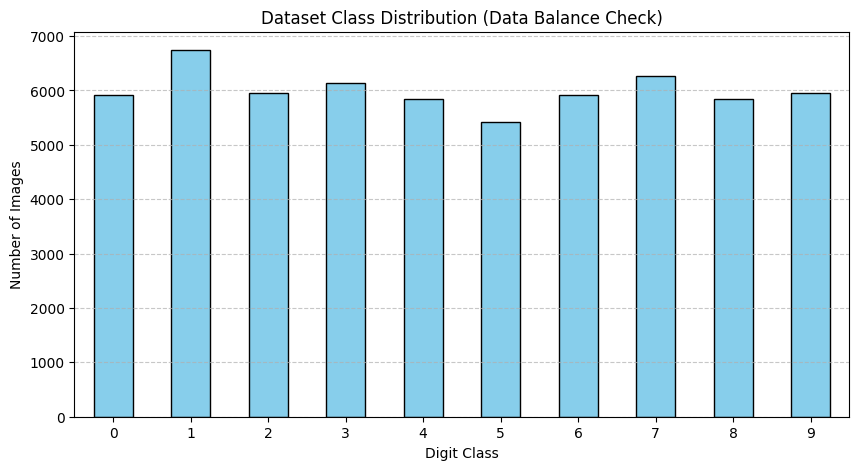

In [5]:
#-- Check that Dataset lost balances or not. --#
import matplotlib.pyplot as plt
saved_dir = '../Figures'
#- Calculate number and ratio of each class. --#
counts = combined_df[label_column].value_counts().sort_index()
percentages = (counts / len(combined_df)) * 100
print("-" * 56)
print("Class Distribution Check:")
for number, count in counts.items():
    pct = percentages[number]
    print(f"number {number}: {count} images ({pct:.2f}%)")
#-- Draw the diagram. --#
plt.figure(figsize=(10, 5))
counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Dataset Class Distribution (Data Balance Check)')
plt.xlabel('Digit Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
output_path = os.path.join(saved_dir, 'Digit_Class_Distribution.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight') # dpi=300 giúp ảnh nét, bbox_inches tránh bị cắt lẹm viền
print(f"\nSaved figure to: {output_path}")
plt.show()

The ../Figures exists

Saved figure to: ../Figures\Digit Class Distribution.png


<Figure size 640x480 with 0 Axes>

## Level 3: Data Quality Analysis ##

In [39]:
import cv2
#-- Collect first smaple data from combined_df. --#
sample_row = sample_row = combined_df.iloc[0]
pixel_values = sample_row.iloc[1:].values
image_size = int(np.sqrt(len(pixel_values)))
#-- Conver pixel into 2D. --#
img_2d = pixel_values.reshape((image_size, image_size)).astype(np.uint8)
#-- Calculate Laplace Variance. --#
laplacian_var = cv2.Laplacian(img_2d, cv2.CV_64F).var()
print(f"Laplacian Variance score: {laplacian_var:.2f}")
#-- Check image is blurry or not. --#
threshold = 100.0
if laplacian_var < threshold:
    print("Image seems blurry")
else:
    print("Image is clear, not blurry")


Laplacian Variance score: 10755.08
Image is clear, not blurry


In [40]:
#-- Get the 2D image from the first sample. --#
sample_row = combined_df.iloc[0]
pixel_values = sample_row.iloc[1:].values
image_size = int(np.sqrt(len(pixel_values)))
img_2d = pixel_values.reshape((image_size, image_size))
#-- Extract the top, bottom, left, and right outer edges. --#
top_edge = img_2d[0, :]
bottom_edge = img_2d[-1, :]
left_edge = img_2d[:, 0]
right_edge = img_2d[:, -1]
#-- Check if any pixels on the edges differ significantly from the background color. --#
background_color = img_2d[0, 0] #-- Sample the background color from the corner. --#
threshold_diff = 50
is_cropped = False
if (abs(top_edge - background_color) > threshold_diff).any() or \
   (abs(bottom_edge - background_color) > threshold_diff).any() or \
   (abs(left_edge - background_color) > threshold_diff).any() or \
   (abs(right_edge - background_color) > threshold_diff).any():
    is_cropped = True
#-- onclusion. --#
if is_cropped:
    print("The image SEEMS to be cropped/cut off (touches or overflows the border).")
else:
    print("The image is NOT cropped; the digit is fully contained within the frame.")

The image is NOT cropped; the digit is fully contained within the frame.


In [ ]:
sample_row = combined_df.iloc[0]
pixel_values = sample_row.iloc[1:].valuesS
image_size = int(np.sqrt(len(pixel_values)))
img_2d = pixel_values.reshape((image_size, image_size)).astype(float)

corner_pixels = np.concatenate([
    img_2d[:3, :3].flatten(),
    img_2d[:3, -3:].flatten(),
    img_2d[-3:, :3].flatten(),
    img_2d[-3:, -3:].flatten()
])

background_std = np.std(corner_pixels)
print(f"Background Standard Deviation (Noise score): {background_std:.2f}")

noise_threshold = 10.0
if background_std > noise_threshold:
    print("The image SEEMS to be noisy.")
else:
    print("The image is clean, no significant noise detected.")

Background Standard Deviation (Noise score): 0.00
The image is clean, no significant noise detected.
